In [1]:
import os
import sqlite3
import struct
from io import BytesIO
import tarfile
import logging

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from dotenv import load_dotenv
from transformers import AutoProcessor, AutoModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from schema import setup_db
from hotdog import initial_setup

%load_ext autoreload
%autoreload 2

load_dotenv()
setup_db()

DB = os.environ.get('DB', 'embedding.db')
FOOD_TAR_PATH = os.environ.get('FOOD_TAR_PATH')

# Change MODEL_ID to switch variants:
#   google/siglip2-base-patch16-224   (768-dim)
#   google/siglip2-large-patch16-256  (1024-dim)
#   google/siglip2-so400m-patch14-384 (1152-dim)
MODEL_ID = 'google/siglip2-base-patch16-224'
MODEL_NAME = MODEL_ID.split('/')[-1]

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

EMBEDDING_DIM = model.config.vision_config.hidden_size
EMBEDDING_FMT = f'{EMBEDDING_DIM}f'
print(f'{MODEL_ID}  embedding_dim={EMBEDDING_DIM}')

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

google/siglip2-base-patch16-224  embedding_dim=768


In [3]:
%%time
df = initial_setup(model=MODEL_NAME)

  0%|          | 0/101112 [00:00<?, ?it/s]

CPU times: user 16.7 s, sys: 1.61 s, total: 18.3 s
Wall time: 1min 28s


In [4]:
%%time
with sqlite3.connect(DB) as conn:
    sql = "SELECT id FROM embeddings WHERE embedding IS NOT NULL AND model = ?"
    known_ids = set(pd.read_sql(sql, conn, params=(MODEL_NAME,))['id'].tolist())
print(f'{len(known_ids)} embeddings already computed')

with tarfile.open(FOOD_TAR_PATH, 'r:gz') as tar:
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        if row['id'] in known_ids:
            continue
        member = tar.getmember(row['path'])
        try:
            with tar.extractfile(member) as member_file:
                image = Image.open(BytesIO(member_file.read())).convert('RGB')
                inputs = processor(images=image, return_tensors='pt').to(device)
                with torch.no_grad():
                    out = model.get_image_features(**inputs)
                v = out.pooler_output[0].cpu().numpy().tolist()
                with sqlite3.connect(DB) as conn:
                    conn.execute(
                        'UPDATE embeddings SET embedding = ? WHERE id = ? AND model = ?',
                        (struct.pack(EMBEDDING_FMT, *v), row['id'], MODEL_NAME)
                    )
        except Exception as ex:
            logging.error(ex)
            logging.error(row['path'])

0 embeddings already computed


  0%|          | 0/101000 [00:00<?, ?it/s]

CPU times: user 42min 40s, sys: 4min 50s, total: 47min 30s
Wall time: 3h 6min 24s


In [5]:
with sqlite3.connect(DB) as conn:
    embeddings_df = pd.read_sql(
        "SELECT * FROM embeddings WHERE model = ?", conn, params=(MODEL_NAME,)
    )
embeddings_df['embedding'] = embeddings_df['embedding'].map(
    lambda x: np.array(struct.unpack(EMBEDDING_FMT, x))
)
embeddings_df

,id,model,path,label,embedding
0,2885220,siglip2-base-patch16-224,food-101/images/beignets/2885220.jpg,beignets,"[-0.02321380376815796, 0.2631184458732605, -0...."
1,1814040,siglip2-base-patch16-224,food-101/images/beignets/1814040.jpg,beignets,"[0.15985077619552612, 0.45425862073898315, 0.1..."
2,81202,siglip2-base-patch16-224,food-101/images/beignets/81202.jpg,beignets,"[-0.23697757720947266, 0.7384510040283203, 0.1..."
3,1827892,siglip2-base-patch16-224,food-101/images/beignets/1827892.jpg,beignets,"[0.012306928634643555, 0.5670986175537109, -0...."
4,2802124,siglip2-base-patch16-224,food-101/images/beignets/2802124.jpg,beignets,"[-0.09753227233886719, 0.16930556297302246, 0...."
...,...,...,...,...,...
100995,2635081,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/2635081.jpg,spaghetti_bolognese,"[0.29288673400878906, 0.22605222463607788, -0...."
100996,3614721,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/3614721.jpg,spaghetti_bolognese,"[0.09227913618087769, 1.005260705947876, -0.47..."
100997,1277517,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/1277517.jpg,spaghetti_bolognese,"[0.28184205293655396, 0.29007184505462646, -0...."
100998,3353469,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/3353469.jpg,spaghetti_bolognese,"[0.23070555925369263, 0.568324625492096, -0.57..."


In [ ]:
with open('labels.txt') as f:
    label_txt = [l.strip() for l in f.readlines()]
with open('classes.txt') as f:
    classes_txt = [l.strip() for l in f.readlines()]

# SigLIP2 performs significantly better with a prompt template than bare label names.
prompted = [f'a photo of a {l.lower()}' for l in label_txt]

inputs = processor(text=prompted, return_tensors='pt', padding='max_length').to(device)
with torch.no_grad():
    text_out = model.get_text_features(**inputs)
text_features = text_out.pooler_output
text_features = text_features / text_features.norm(dim=-1, keepdim=True)
text_features_np = text_features.cpu().numpy()

In [7]:
%%time
img_matrix = np.stack(embeddings_df['embedding'].tolist())
img_matrix = img_matrix / np.linalg.norm(img_matrix, axis=1, keepdims=True)
sims = img_matrix @ text_features_np.T  # (N, 101)
pred_indices = np.argmax(sims, axis=1)
predictions = {row['id']: classes_txt[pred_idx]
               for (_, row), pred_idx in zip(embeddings_df.iterrows(), pred_indices)}

CPU times: user 1.88 s, sys: 1.1 s, total: 2.98 s
Wall time: 3.37 s


In [8]:
with sqlite3.connect(DB) as conn:
    conn.executemany(
        'INSERT OR IGNORE INTO predictions (id, model, predicted_label) VALUES (?, ?, ?)',
        [(k, MODEL_NAME, v) for k, v in predictions.items()]
    )

In [9]:
%%time
with sqlite3.connect(DB) as conn:
    combined_df = pd.read_sql('''
        SELECT embeddings.*, predicted_label
        FROM embeddings
        LEFT JOIN predictions
            ON embeddings.id = predictions.id AND embeddings.model = predictions.model
        WHERE embeddings.model = ?
    ''', conn, params=(MODEL_NAME,))
combined_df['embedding'] = combined_df['embedding'].map(
    lambda x: np.array(struct.unpack(EMBEDDING_FMT, x))
)
combined_df

CPU times: user 4.16 s, sys: 1.26 s, total: 5.42 s
Wall time: 11.4 s


,id,model,path,label,embedding,predicted_label
0,2885220,siglip2-base-patch16-224,food-101/images/beignets/2885220.jpg,beignets,"[-0.02321380376815796, 0.2631184458732605, -0....",cheesecake
1,1814040,siglip2-base-patch16-224,food-101/images/beignets/1814040.jpg,beignets,"[0.15985077619552612, 0.45425862073898315, 0.1...",cannoli
2,81202,siglip2-base-patch16-224,food-101/images/beignets/81202.jpg,beignets,"[-0.23697757720947266, 0.7384510040283203, 0.1...",chocolate_mousse
3,1827892,siglip2-base-patch16-224,food-101/images/beignets/1827892.jpg,beignets,"[0.012306928634643555, 0.5670986175537109, -0....",cannoli
4,2802124,siglip2-base-patch16-224,food-101/images/beignets/2802124.jpg,beignets,"[-0.09753227233886719, 0.16930556297302246, 0....",creme_brulee
...,...,...,...,...,...,...
100995,2635081,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/2635081.jpg,spaghetti_bolognese,"[0.29288673400878906, 0.22605222463607788, -0....",spaghetti_bolognese
100996,3614721,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/3614721.jpg,spaghetti_bolognese,"[0.09227913618087769, 1.005260705947876, -0.47...",spaghetti_bolognese
100997,1277517,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/1277517.jpg,spaghetti_bolognese,"[0.28184205293655396, 0.29007184505462646, -0....",spaghetti_bolognese
100998,3353469,siglip2-base-patch16-224,food-101/images/spaghetti_bolognese/3353469.jpg,spaghetti_bolognese,"[0.23070555925369263, 0.568324625492096, -0.57...",spaghetti_bolognese


In [10]:
accuracy = (combined_df['label'] == combined_df['predicted_label']).mean()
print(f'Overall accuracy: {accuracy:.4f}')

mask = combined_df['label'] == 'hot_dog'
recall = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).mean()
print(f'Hot dog recall:   {recall:.4f}')

mask = combined_df['predicted_label'] == 'hot_dog'
precision = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).mean()
print(f'Hot dog precision:{precision:.4f}')

Overall accuracy: 0.4726
Hot dog recall:   0.1770
Hot dog precision:0.9888


In [11]:
# False Negatives: hot dogs predicted as something else
mask = combined_df['label'] == 'hot_dog'
combined_df[mask].groupby('predicted_label').count().sort_values('id', ascending=False)

,id,model,path,label,embedding
predicted_label,,,,,
club_sandwich,349,349,349,349,349
hot_dog,177,177,177,177,177
pulled_pork_sandwich,143,143,143,143,143
grilled_cheese_sandwich,91,91,91,91,91
fish_and_chips,90,90,90,90,90
lobster_roll_sandwich,52,52,52,52,52
spring_rolls,22,22,22,22,22
french_fries,18,18,18,18,18
garlic_bread,9,9,9,9,9


In [12]:
# False Positives: non-hot-dogs predicted as hot dog
mask = combined_df['predicted_label'] == 'hot_dog'
combined_df[mask].groupby('label').count().sort_values('id', ascending=False)

,id,model,path,embedding,predicted_label
label,,,,,
hot_dog,177,177,177,177,177
chicken_curry,1,1,1,1,1
chicken_wings,1,1,1,1,1


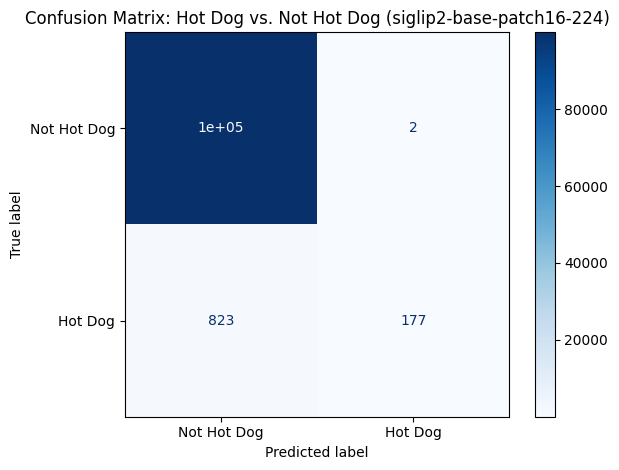

In [13]:
y_true = (combined_df['label'] == 'hot_dog').astype(int)
y_pred = (combined_df['predicted_label'] == 'hot_dog').astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hot Dog', 'Hot Dog'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: Hot Dog vs. Not Hot Dog ({MODEL_NAME})')
plt.tight_layout()
plt.show()